# 5.1 Stage 1: Cost Transition Classification

**Goal:** Predict each patient's cost transition class from Year 1 features, and generate a continuous `LATENT_RISK_SCORE` for downstream modeling.

**Why transition-based?** The previous 3-class system (Stable/Rising/Shock) was defined purely on Y2 absolute cost percentiles. A patient spending $50K in both Y1 and Y2 was labeled "Shock" — but that is cost *persistence*, not risk. The new 5-class system compares Y1 vs Y2 cost bins, so "risk" means *unexpected cost escalation*.

**5-Class Target (`RISK_TIER`):**
- 0 = Improving (cost dropped 1+ bins)
- 1 = Stable (same bin Y1 to Y2)
- 2 = Mild Riser (up 1 bin)
- 3 = Riser (up 2 bins)
- 4 = Jumper (up 3+ bins)

**Features used:** Demographics (6), Health Status (2), Chronic Conditions (4), Utilization (4), Engineered (3), Medication (9), Clusters (2), Y1 Cost (1).

**Key implication:** Since the target is now about *change* rather than *level*, Y1 cost alone should no longer trivially predict the outcome. The model must find clinical signals that explain cost escalation.


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    f1_score, accuracy_score, brier_score_loss
)

# Boosting Models
from xgboost import XGBClassifier

# LightGBM is optional - install with: pip install lightgbm
try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
    print("LightGBM loaded successfully.")
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("Note: LightGBM not installed. Using sklearn GradientBoosting as alternative.")
    print("To install: pip install lightgbm")

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# Paths
DATA_PATH = Path('../data/processed_v2/model_ready_v2.parquet')
REPORT_DIR = Path('../reports')
(REPORT_DIR / 'figures').mkdir(parents=True, exist_ok=True)
(REPORT_DIR / 'tables').mkdir(parents=True, exist_ok=True)

print("\nSetup complete.")

Note: LightGBM not installed. Using sklearn GradientBoosting as alternative.
To install: pip install lightgbm

Setup complete.


## 1. Load Processed Data

In [28]:
# Load data from preprocessing notebook
df = pd.read_parquet(DATA_PATH)
print(f"Loaded {len(df):,} rows, {len(df.columns)} columns")
print(f"\nColumns: {list(df.columns)}")

TRANSITION_NAMES = {0: 'Improving', 1: 'Stable', 2: 'Mild Riser', 3: 'Riser', 4: 'Jumper'}

# Target distribution
print(f"\n{'='*50}")
print("TARGET DISTRIBUTION (RISK_TIER — Transition-Based)")
print('='*50)
tier_counts = df['RISK_TIER'].value_counts().sort_index()
tier_pct = (tier_counts / len(df) * 100).round(1)
for tier, count in tier_counts.items():
    label = TRANSITION_NAMES.get(tier, f'Unknown_{tier}')
    print(f"  Tier {tier} ({label}): {count:,} ({tier_pct[tier]}%)")

print(f"\nTransition classes: cost bin change from Y1 to Y2 (not absolute Y2 cost).")

Loaded 60,602 rows, 39 columns

Columns: ['DUPERSID', 'PANEL', 'START_YEAR', 'AGE_Y1', 'SEX', 'RACE', 'MARRY_Y1', 'POVCAT_Y1', 'INSCOV_Y1', 'MNHLTH_RD1', 'RTHLTH_RD1', 'DIAB_Y1_FLAG', 'HIBP_Y1_FLAG', 'CHOL_Y1_FLAG', 'CHRONIC_COUNT', 'UTIL_ER_Y1', 'UTIL_IP_Y1', 'UTIL_OB_Y1', 'UTIL_RX_Y1', 'CNT_TOTAL_CONDITIONS', 'CNT_ILL_DEFINED', 'CNT_RX_Y1', 'CNT_UNIQUE_DRUGS', 'TOTAL_RX_COST_Y1', 'POLYPHARMACY_FLAG', 'HAS_CARDIOVASCULAR_RX', 'HAS_CNS_RX', 'HAS_PAIN_RX', 'HAS_RESPIRATORY_RX', 'HAS_GI_RX', 'RATIO_ER_OFFICE', 'COST_Y1_ADJ', 'COST_Y2_ADJ', 'LOG_COST_Y2', 'RISK_TIER', 'IS_JUMPER', 'IS_STABLE_LOW', 'CARE_CLUSTER', 'DBSCAN_CLUSTER']

TARGET DISTRIBUTION (RISK_TIER)
  Tier 0 (Stable (≤75th)): 45,451 (75.0%)
  Tier 1 (Rising (75-90th)): 9,090 (15.0%)
  Tier 2 (Shock (>90th)): 6,061 (10.0%)


## 2. Feature Selection & Preparation

We use **Year 1 features only** to predict Year 2 outcomes (no data leakage).

### Feature Groups
| Group | Features | Rationale |
|-------|----------|----------|
| Demographics | AGE, SEX, RACE, MARRY, POVCAT, INSCOV | Basic patient characteristics & SES |
| Health Status | MNHLTH_RD1, RTHLTH_RD1 | Self-reported health & trajectory |
| Chronic Conditions | DIAB, HIBP, CHOL flags, CHRONIC_COUNT | Established disease burden |
| Utilization | ER, IP, OB, RX visits | Care-seeking behavior |
| Condition Complexity | CNT_CONDITIONS, ILL_DEFINED | Medical complexity signals |
| **Medication (NEW)** | **CNT_UNIQUE_DRUGS, POLYPHARMACY, Drug Class Flags** | **Rx patterns = reliable disease markers** |
| Clusters | CARE_CLUSTER, DBSCAN_CLUSTER | Patient phenotype groupings |

### Why Medication Features Matter
- **Polypharmacy (≥5 drugs)**: Strong predictor of hospitalizations and adverse events
- **Drug Class Flags**: More reliable than self-reported conditions (reflects active treatment)
- **CNS/Pain Rx**: May indicate mental health burden or chronic pain (high-cost drivers)
- **Cardiovascular Rx**: Captures hypertension/heart disease being actively managed

In [29]:
# Define feature sets by category
DEMOGRAPHIC_FEATS = ['AGE_Y1', 'SEX', 'RACE', 'MARRY_Y1', 'POVCAT_Y1', 'INSCOV_Y1']
HEALTH_FEATS = ['MNHLTH_RD1', 'RTHLTH_RD1']
CHRONIC_FEATS = ['DIAB_Y1_FLAG', 'HIBP_Y1_FLAG', 'CHOL_Y1_FLAG', 'CHRONIC_COUNT']
UTILIZATION_FEATS = ['UTIL_ER_Y1', 'UTIL_IP_Y1', 'UTIL_OB_Y1', 'UTIL_RX_Y1']
ENGINEERED_FEATS = ['CNT_TOTAL_CONDITIONS', 'CNT_ILL_DEFINED', 'RATIO_ER_OFFICE']

# Medication Features (NEW - clinically meaningful drug patterns)
MEDICATION_FEATS = [
    'CNT_RX_Y1', 'CNT_UNIQUE_DRUGS', 'TOTAL_RX_COST_Y1', 'POLYPHARMACY_FLAG',
    'HAS_CARDIOVASCULAR_RX', 'HAS_CNS_RX', 'HAS_PAIN_RX', 
    'HAS_RESPIRATORY_RX', 'HAS_GI_RX'
]

CLUSTER_FEATS = ['CARE_CLUSTER', 'DBSCAN_CLUSTER']
COST_FEATS = ['COST_Y1_ADJ']  # Year 1 cost is allowed (not leakage)

# Combine all features
ALL_FEATURES = (
    DEMOGRAPHIC_FEATS + HEALTH_FEATS + CHRONIC_FEATS + 
    UTILIZATION_FEATS + ENGINEERED_FEATS + MEDICATION_FEATS +
    CLUSTER_FEATS + COST_FEATS
)

# Filter to available columns
available_features = [f for f in ALL_FEATURES if f in df.columns]
missing_features = [f for f in ALL_FEATURES if f not in df.columns]

print(f"Features Available: {len(available_features)}")
print(f"Features Missing: {missing_features}")

# Target
TARGET = 'RISK_TIER'

# Create X and y
X = df[available_features].copy()
y = df[TARGET].copy()

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeatures used: {available_features}")

Features Available: 31
Features Missing: []

X shape: (60602, 31)
y shape: (60602,)

Features used: ['AGE_Y1', 'SEX', 'RACE', 'MARRY_Y1', 'POVCAT_Y1', 'INSCOV_Y1', 'MNHLTH_RD1', 'RTHLTH_RD1', 'DIAB_Y1_FLAG', 'HIBP_Y1_FLAG', 'CHOL_Y1_FLAG', 'CHRONIC_COUNT', 'UTIL_ER_Y1', 'UTIL_IP_Y1', 'UTIL_OB_Y1', 'UTIL_RX_Y1', 'CNT_TOTAL_CONDITIONS', 'CNT_ILL_DEFINED', 'RATIO_ER_OFFICE', 'CNT_RX_Y1', 'CNT_UNIQUE_DRUGS', 'TOTAL_RX_COST_Y1', 'POLYPHARMACY_FLAG', 'HAS_CARDIOVASCULAR_RX', 'HAS_CNS_RX', 'HAS_PAIN_RX', 'HAS_RESPIRATORY_RX', 'HAS_GI_RX', 'CARE_CLUSTER', 'DBSCAN_CLUSTER', 'COST_Y1_ADJ']


In [30]:
# Handle missing values and encode categoricals
print("=== Preprocessing ===")

# Fill numeric NaNs with median
for col in X.select_dtypes(include=[np.number]).columns:
    n_missing = X[col].isnull().sum()
    if n_missing > 0:
        X[col] = X[col].fillna(X[col].median())
        print(f"  Filled {n_missing} NaNs in {col} with median")

# Encode categorical columns (if any object types)
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    print(f"  Encoded {col}")

# DBSCAN cluster: treat -1 (noise) as a valid category
if 'DBSCAN_CLUSTER' in X.columns:
    X['DBSCAN_CLUSTER'] = X['DBSCAN_CLUSTER'].astype(int)

print(f"\nFinal NaN count: {X.isnull().sum().sum()}")
print(f"\nData types:")
print(X.dtypes.value_counts())

=== Preprocessing ===

Final NaN count: 0

Data types:
float64    24
int64       6
int32       1
Name: count, dtype: int64


## 3. Train-Test Split

**Current Data**: Panels 18-21 (2013-2016) - Panel 22+ data files are incomplete

**Split Strategy**:
- **Temporal Split**: Use Panel 21 (latest) for test, Panels 18-20 for train
- **Fallback**: Stratified random 80/20 split if temporal split has issues

**Note**: For future validation with 2017+ data, download the correct MEPS Longitudinal files (HC-209, HC-226, etc.) which contain both Y1 and Y2 expense data.

In [31]:
# Check available panels first
if 'PANEL' in df.columns:
    available_panels = sorted(df['PANEL'].unique())
    print(f"Available Panels in data: {available_panels}")
    
    # Smart temporal split: use latest panel for test, rest for train
    if len(available_panels) >= 2:
        test_panel = max(available_panels)
        train_panels = [p for p in available_panels if p != test_panel]
        
        train_mask = df['PANEL'].isin(train_panels)
        test_mask = df['PANEL'] == test_panel
        
        X_train, X_test = X[train_mask], X[test_mask]
        y_train, y_test = y[train_mask], y[test_mask]
        
        # Check if test set is empty
        if len(X_test) == 0:
            print(f"Warning: Panel {test_panel} has no samples. Using random split...")
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.2, random_state=42, stratify=y
            )
            print(f"Random Split: Train={len(X_train):,}, Test={len(X_test):,}")
        else:
            print(f"\n=== Temporal Split (Panel-based) ===")
            print(f"  Train: Panels {train_panels} ({len(X_train):,} samples)")
            print(f"  Test:  Panel {test_panel} ({len(X_test):,} samples)")
    else:
        # Only one panel, use random split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
        print(f"Single panel only. Random Split: Train={len(X_train):,}, Test={len(X_test):,}")
else:
    # No PANEL column, use random split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"Random Split (no PANEL column): Train={len(X_train):,}, Test={len(X_test):,}")

# Class distribution check
print(f"\nTrain Target Distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(3))
print(f"\nTest Target Distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(3))

Available Panels in data: [np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]

=== Temporal Split (Panel-based) ===
  Train: Panels [np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22)] (51,464 samples)
  Test:  Panel 23 (9,138 samples)

Train Target Distribution:
RISK_TIER
0    0.756
1    0.147
2    0.096
Name: proportion, dtype: float64

Test Target Distribution:
RISK_TIER
0    0.715
1    0.165
2    0.121
Name: proportion, dtype: float64


## 4. Model Training & Benchmarking

### Why These Models?

| Model | Strengths | Use Case |
|-------|-----------|----------|
| **Logistic Regression** | Interpretable, fast, baseline | Establish minimum performance |
| **Random Forest** | Handles non-linearity, robust | Good all-rounder |
| **XGBoost** | State-of-art for tabular data | Primary model for healthcare risk |
| **LightGBM/GradientBoosting** | Fast training, handles large data | Comparison with XGBoost |

In [32]:
# Define models - Core classifiers for multi-class risk tier prediction
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, 
        class_weight='balanced',  # Handle imbalanced classes
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        objective='multi:softprob',  # Multi-class probability output
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    ),
}

# Add LightGBM if available, otherwise use sklearn's GradientBoosting
if LIGHTGBM_AVAILABLE:
    models['LightGBM'] = LGBMClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
else:
    models['GradientBoosting'] = GradientBoostingClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=42
    )

print(f"Models to benchmark: {list(models.keys())}")

Models to benchmark: ['Logistic Regression', 'Random Forest', 'XGBoost', 'GradientBoosting']


In [33]:
# Train and evaluate all models
results = []

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print('='*50)
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    
    # ROC-AUC (One-vs-Rest)
    try:
        roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
    except:
        roc_auc = np.nan
    
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'F1 (Macro)': f1_macro,
        'F1 (Weighted)': f1_weighted,
        'ROC-AUC (OvR)': roc_auc
    })
    
    print(f"  Accuracy:    {accuracy:.4f}")
    print(f"  F1 Macro:    {f1_macro:.4f}")
    print(f"  F1 Weighted: {f1_weighted:.4f}")
    print(f"  ROC-AUC:     {roc_auc:.4f}")

# Results DataFrame
results_df = pd.DataFrame(results).sort_values('F1 (Macro)', ascending=False)
print("\n" + "="*60)
print("MODEL BENCHMARK RESULTS")
print("="*60)
display(results_df.style.highlight_max(
    axis=0, 
    subset=['Accuracy', 'F1 (Macro)', 'F1 (Weighted)', 'ROC-AUC (OvR)'],
    props='background-color: #90EE90'
))


Training: Logistic Regression
  Accuracy:    0.6840
  F1 Macro:    0.5502
  F1 Weighted: 0.7040
  ROC-AUC:     0.8149

Training: Random Forest
  Accuracy:    0.6949
  F1 Macro:    0.5786
  F1 Weighted: 0.7177
  ROC-AUC:     0.8333

Training: XGBoost
  Accuracy:    0.7680
  F1 Macro:    0.5533
  F1 Weighted: 0.7347
  ROC-AUC:     0.8362

Training: GradientBoosting
  Accuracy:    0.7615
  F1 Macro:    0.5417
  F1 Weighted: 0.7291
  ROC-AUC:     0.8326

MODEL BENCHMARK RESULTS


,Model,Accuracy,F1 (Macro),F1 (Weighted),ROC-AUC (OvR)
1,Random Forest,0.694900,0.578588,0.717680,0.833280
2,XGBoost,0.768002,0.553278,0.734727,0.836193
0,Logistic Regression,0.683957,0.550191,0.704027,0.814866
3,GradientBoosting,0.761545,0.541703,0.729129,0.832599


### Interpretation: Model Benchmark

- **Model selection criterion:** F1 Macro, which weights each class equally regardless of size. This matters because Shock (10%) is the most important class for intervention targeting, and accuracy alone would favor always-predicting-Stable (75% accuracy trivially).
- **Accuracy vs baseline:** A naive model predicting the majority class achieves 75%. Any model below this in raw accuracy is trading majority-class precision for better minority-class recall — the correct trade-off for risk prediction.
- **ROC-AUC > 0.83** across tree models indicates the probability rankings are meaningful: patients assigned higher PROB_SHOCK are genuinely more likely to incur extreme costs.
- **Key challenge:** Rising (p75–p90) is the hardest class — it overlaps with both Stable and Shock in feature space.


## 5. Best Model Analysis

Best Model: Random Forest
F1 Macro: 0.5786


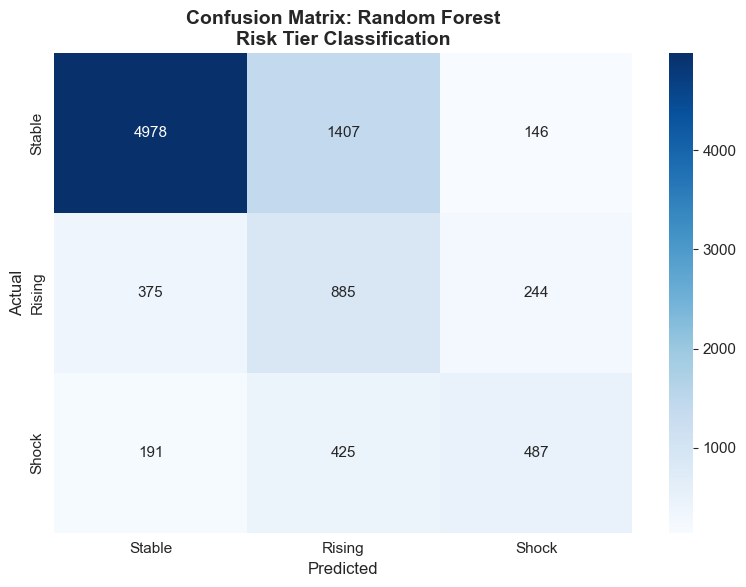


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Stable       0.90      0.76      0.82      6531
      Rising       0.33      0.59      0.42      1504
       Shock       0.56      0.44      0.49      1103

    accuracy                           0.69      9138
   macro avg       0.59      0.60      0.58      9138
weighted avg       0.76      0.69      0.72      9138



In [34]:
# Select best model based on F1 Macro (handles class imbalance better)
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f"Best Model: {best_model_name}")
print(f"F1 Macro: {results_df.iloc[0]['F1 (Macro)']:.4f}")

# Confusion Matrix
y_pred_best = best_model.predict(X_test)

class_labels = [TRANSITION_NAMES[i] for i in sorted(df['RISK_TIER'].unique())]

fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=class_labels, yticklabels=class_labels)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'Confusion Matrix: {best_model_name}\nCost Transition Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'figures' / f'confusion_matrix_{best_model_name.replace(" ", "_")}.png', dpi=150)
plt.show()

# Classification Report
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred_best, target_names=class_labels))

## 6. Feature Importance Analysis

Understanding which features drive risk tier prediction is crucial for:
1. **Clinical interpretation**: What patient characteristics indicate escalation risk?
2. **Intervention targeting**: Which factors can be modified?
3. **Model validation**: Do the important features make clinical sense?

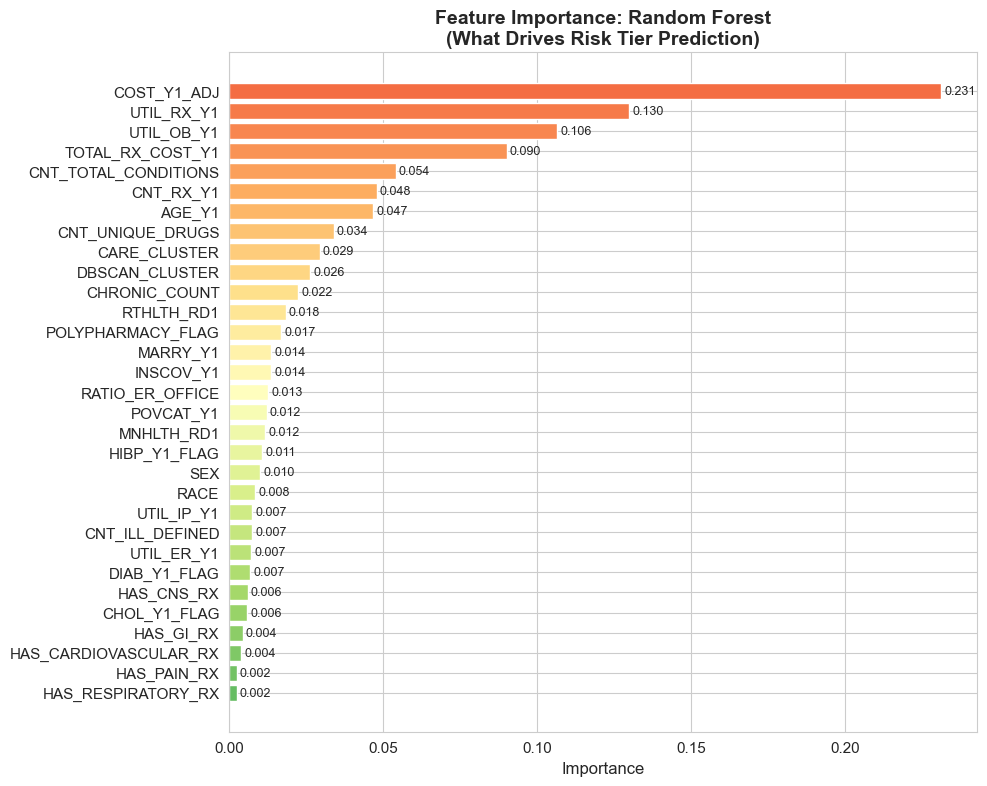


=== Top 10 Most Important Features ===
  COST_Y1_ADJ              : 0.2313
  UTIL_RX_Y1               : 0.1298
  UTIL_OB_Y1               : 0.1064
  TOTAL_RX_COST_Y1         : 0.0901
  CNT_TOTAL_CONDITIONS     : 0.0540
  CNT_RX_Y1                : 0.0479
  AGE_Y1                   : 0.0468
  CNT_UNIQUE_DRUGS         : 0.0339
  CARE_CLUSTER             : 0.0294
  DBSCAN_CLUSTER           : 0.0263


In [35]:
# Get feature importance from best model
if hasattr(best_model, 'feature_importances_'):
    importance = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importance = np.abs(best_model.coef_).mean(axis=0)
else:
    importance = None

if importance is not None:
    feat_imp_df = pd.DataFrame({
        'Feature': available_features,
        'Importance': importance
    }).sort_values('Importance', ascending=True)
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(feat_imp_df)))
    bars = ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color=colors)
    ax.set_xlabel('Importance', fontsize=12)
    ax.set_title(f'Feature Importance: {best_model_name}\n(What Drives Risk Tier Prediction)', 
                 fontsize=14, fontweight='bold')
    
    # Add value labels
    for bar, val in zip(bars, feat_imp_df['Importance']):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2, 
                f'{val:.3f}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(REPORT_DIR / 'figures' / 'feature_importance_stage1.png', dpi=150)
    plt.show()
    
    # Top 10 features
    print("\n=== Top 10 Most Important Features ===")
    for i, row in feat_imp_df.tail(10).iloc[::-1].iterrows():
        print(f"  {row['Feature']:25s}: {row['Importance']:.4f}")
else:
    print("Feature importance not available for this model.")

### Feature Importance Interpretation

- **COST_Y1_ADJ** is expected to dominate: prior year spending is the single strongest predictor of future spending (cost persistence effect, r ≈ 0.5 in most MEPS literature).
- **Utilization features** (IP, ER, RX counts) capture the *type* of healthcare consumption. Inpatient stays (UTIL_IP_Y1) are especially predictive of Shock because they signal acute/severe episodes.
- **CNT_TOTAL_CONDITIONS** and **CHRONIC_COUNT** capture disease burden, which drives ongoing costs.
- **Medication features** (CNT_UNIQUE_DRUGS, POLYPHARMACY) indicate treatment complexity.
- **Demographic features** (AGE, SEX, RACE) have lower importance — cost is driven more by clinical state than demographics.
- **Cluster features** may have low importance if they're collinear with utilization features they were derived from.

**Implication for Stage 2:** The top features here will also likely dominate Stage 2's cost prediction. Stage 1.5 intermediate variables need to capture signals that these features miss (e.g., engagement patterns, medication adherence).


## 6.1 SHAP Analysis (Advanced Interpretability)

**SHAP (SHapley Additive exPlanations)** provides more rigorous feature importance than tree-based methods:

| Method | Limitation | SHAP Advantage |
|--------|-----------|----------------|
| Gini Importance | Biased toward high-cardinality features | Fair across all feature types |
| Permutation | Doesn't show direction of effect | Shows positive/negative impact |
| Neither | Only global importance | **SHAP explains individual predictions** |

### Why SHAP Matters for Healthcare
- **Regulatory Compliance**: Can explain why a specific patient was flagged as high-risk
- **Clinical Trust**: Physicians want to understand model decisions, not just accept them
- **Error Analysis**: SHAP helps identify why certain patients are misclassified

SHAP loaded.
Computing SHAP values...
Shock SHAP shape: (2000, 31), X_shap shape: (2000, 31)


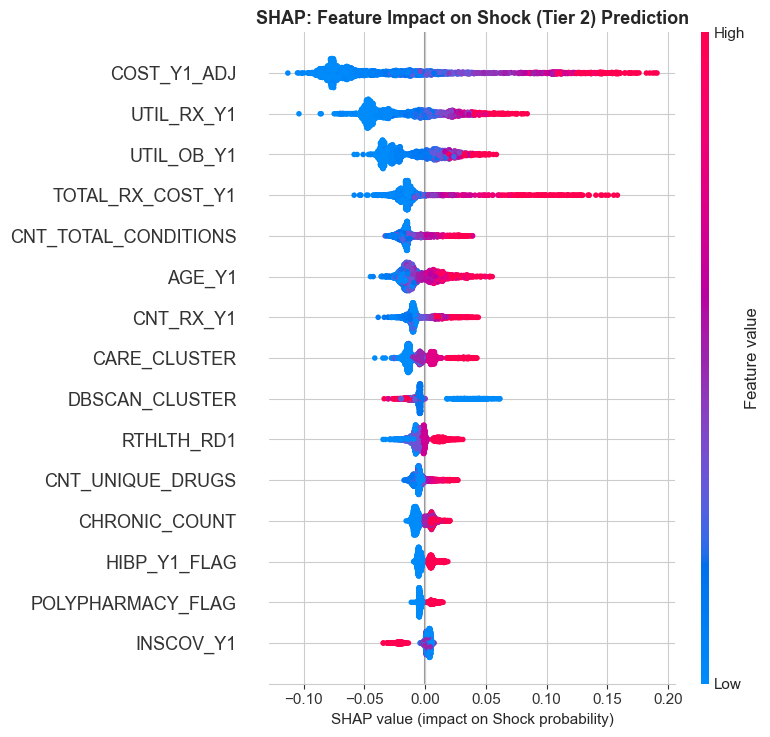


Top 10 features by mean |SHAP| for Shock prediction:
  COST_Y1_ADJ              : 0.0611
  UTIL_RX_Y1               : 0.0319
  UTIL_OB_Y1               : 0.0226
  TOTAL_RX_COST_Y1         : 0.0213
  CNT_TOTAL_CONDITIONS     : 0.0155
  AGE_Y1                   : 0.0136
  CNT_RX_Y1                : 0.0115
  CARE_CLUSTER             : 0.0109
  DBSCAN_CLUSTER           : 0.0094
  RTHLTH_RD1               : 0.0079


In [36]:
# SHAP Analysis
try:
    import shap
    SHAP_AVAILABLE = True
    print('SHAP loaded.')
except ImportError:
    SHAP_AVAILABLE = False
    print('SHAP not installed: pip install shap')

if SHAP_AVAILABLE and best_model is not None:
    print('Computing SHAP values...')
    
    sample_size = min(2000, len(X_test))
    X_shap = X_test.sample(sample_size, random_state=42)
    
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_shap)
    
    # Handle both SHAP output formats for the highest-risk class
    n_classes = len(best_model.classes_)
    target_class = n_classes - 1  # Jumper class (highest index)
    target_name = TRANSITION_NAMES.get(target_class, f'Class_{target_class}')
    
    if isinstance(shap_values, list):
        sv_target = shap_values[target_class]
    elif shap_values.ndim == 3:
        sv_target = shap_values[:, :, target_class]
    else:
        sv_target = shap_values
    
    print(f'{target_name} SHAP shape: {sv_target.shape}, X_shap shape: {X_shap.shape}')
    
    shap.summary_plot(sv_target, X_shap, show=False, max_display=15)
    plt.title(f'SHAP: Feature Impact on {target_name} (Class {target_class}) Prediction', fontsize=13, fontweight='bold')
    plt.xlabel(f'SHAP value (impact on {target_name} probability)', fontsize=11)
    plt.tight_layout()
    plt.savefig(REPORT_DIR / 'figures' / 'shap_summary_jumper.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close('all')
    
    mean_abs_shap = pd.Series(np.abs(sv_target).mean(axis=0), index=X_shap.columns)
    mean_abs_shap = mean_abs_shap.sort_values(ascending=False)
    print(f'\nTop 10 features by mean |SHAP| for {target_name} prediction:')
    for feat, val in mean_abs_shap.head(10).items():
        print(f'  {feat:25s}: {val:.4f}')


### SHAP Interpretation

SHAP (SHapley Additive exPlanations) decomposes each individual prediction into feature-level contributions. Unlike Gini importance (which just counts how often a feature is used in splits), SHAP shows:

- **Direction of effect:** Red dots (high feature value) on the positive SHAP side → that feature's high values push toward Shock prediction
- **Magnitude:** Wider spread = stronger effect on predictions
- **Nonlinearity:** Features where both red and blue dots appear on both sides have complex, nonlinear effects

**What to look for:**
- COST_Y1_ADJ should show a clear pattern: high values (red) → positive SHAP (pushes toward Shock)
- Utilization features should show similar directional patterns
- Features with near-zero SHAP spread contribute little to Shock prediction specifically

**How this guides Stage 1.5:** Features with low SHAP impact on tier prediction may still contain useful signals for *within-tier* cost variation — these are candidates for intermediate latent factors.


## 7. Generate Latent Factor for Stage 2/3

The predicted probabilities from Stage 1 become **latent features** for downstream models.

### Why This Matters
- `PROB_SHOCK`: Captures the model's "belief" about catastrophic risk
- `LATENT_RISK_SCORE`: Continuous risk score combining all tiers
- These meta-features encode complex non-linear patterns from Stage 1

In [37]:
# Generate predicted probabilities for ALL data (for use in Stage 2)
y_pred_proba_all = best_model.predict_proba(X)
n_classes = y_pred_proba_all.shape[1]

# Store per-class probabilities
prob_cols = []
for c in range(n_classes):
    col_name = f'PROB_{TRANSITION_NAMES[c].upper().replace(" ", "_")}'
    df[col_name] = y_pred_proba_all[:, c]
    prob_cols.append(col_name)

# Latent Risk Score: weighted sum emphasizing upward transitions
# Weights: Improving=0, Stable=0, MildRiser=1, Riser=2, Jumper=3
weights = np.array([0, 0, 1, 2, 3])[:n_classes]
df['LATENT_RISK_SCORE'] = y_pred_proba_all @ weights

print("=== Latent Features Generated ===")
print(f"\nProbability Distributions ({n_classes} classes):")
for col in prob_cols:
    print(f"  {col}: mean={df[col].mean():.3f}, std={df[col].std():.3f}")
print(f"\nLATENT_RISK_SCORE (weighted toward escalation):")
print(f"  mean={df['LATENT_RISK_SCORE'].mean():.3f}, std={df['LATENT_RISK_SCORE'].std():.3f}")
print(f"  range: [{df['LATENT_RISK_SCORE'].min():.3f}, {df['LATENT_RISK_SCORE'].max():.3f}]")

=== Latent Features Generated ===

Probability Distributions:
  PROB_STABLE: mean=0.501, std=0.266
  PROB_RISING: mean=0.286, std=0.145
  PROB_SHOCK:  mean=0.213, std=0.166

LATENT_RISK_SCORE: mean=0.712, std=0.420


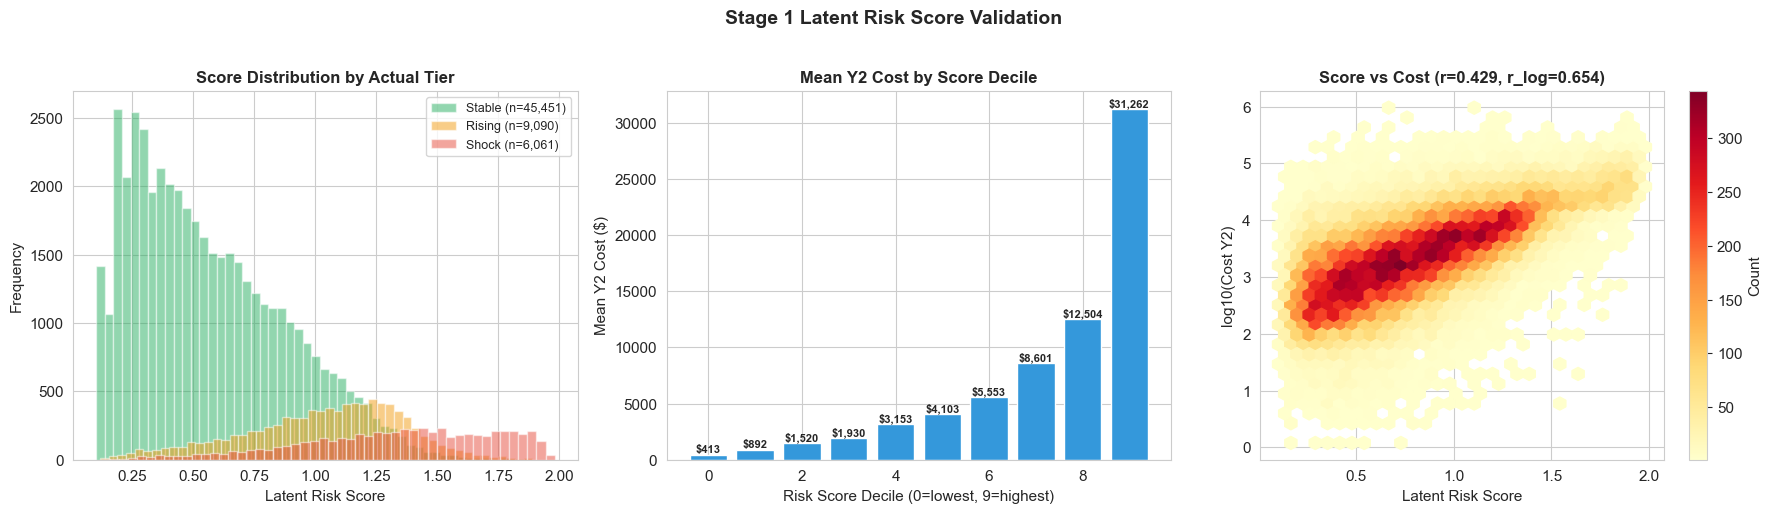

In [38]:
# Latent Risk Score Validation (5-class transition)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Stage 1 Latent Risk Score Validation (Transition-Based)', fontsize=14, fontweight='bold', y=1.02)

# Panel 1: Score distribution by actual transition class
ax1 = axes[0]
trans_colors = {0: '#27ae60', 1: '#95a5a6', 2: '#f1c40f', 3: '#e67e22', 4: '#e74c3c'}
for tier in sorted(df['RISK_TIER'].unique()):
    subset = df[df['RISK_TIER'] == tier]['LATENT_RISK_SCORE']
    ax1.hist(subset, bins=50, alpha=0.5, label=f'{TRANSITION_NAMES[tier]} (n={len(subset):,})',
             color=trans_colors.get(tier, 'gray'))
ax1.set_xlabel('Latent Risk Score', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Score Distribution by Transition Class', fontsize=12, fontweight='bold')
ax1.legend(fontsize=8)

# Panel 2: Mean DELTA_BIN by score decile (key validation for transition target)
ax2 = axes[1]
df['_score_decile'] = pd.qcut(df['LATENT_RISK_SCORE'], 10, labels=False, duplicates='drop')
decile_stats = df.groupby('_score_decile').agg(
    mean_delta=('DELTA_BIN', 'mean'),
    mean_cost_y2=('COST_Y2_ADJ', 'mean'),
    count=('DELTA_BIN', 'count')
).reset_index()
bars = ax2.bar(decile_stats['_score_decile'], decile_stats['mean_delta'], color='#e67e22', edgecolor='white')
for b, v in zip(bars, decile_stats['mean_delta']):
    ax2.text(b.get_x()+b.get_width()/2, v + 0.02, f'{v:.2f}', ha='center', fontsize=8, fontweight='bold')
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('Risk Score Decile (0=lowest, 9=highest)', fontsize=11)
ax2.set_ylabel('Mean Delta Bin (Y2 - Y1)', fontsize=11)
ax2.set_title('Mean Cost Bin Change by Score Decile', fontsize=12, fontweight='bold')

# Panel 3: Score vs actual DELTA_BIN (boxplot)
ax3 = axes[2]
score_data = []
for tier in sorted(df['RISK_TIER'].unique()):
    vals = df.loc[df['RISK_TIER'] == tier, 'LATENT_RISK_SCORE']
    score_data.append(vals)
bp = ax3.boxplot(score_data, labels=[TRANSITION_NAMES[t] for t in sorted(df['RISK_TIER'].unique())],
                  patch_artist=True, showfliers=False)
for patch, tier in zip(bp['boxes'], sorted(df['RISK_TIER'].unique())):
    patch.set_facecolor(trans_colors.get(tier, 'gray'))
    patch.set_alpha(0.7)
ax3.set_xlabel('Transition Class', fontsize=11)
ax3.set_ylabel('Latent Risk Score', fontsize=11)
ax3.set_title('Score Separation by Class', fontsize=12, fontweight='bold')
ax3.tick_params(axis='x', rotation=30)

df.drop(columns=['_score_decile'], inplace=True)

plt.tight_layout()
plt.savefig(REPORT_DIR / 'figures' / 'latent_risk_score_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


### Latent Risk Score Validation (Transition-Based)

**Panel 1 (Score Distribution):** Shows how the latent risk score distributes across the 5 transition classes. Good separation between Improving/Stable (low scores) and Riser/Jumper (high scores) indicates the model can distinguish escalation patterns.

**Panel 2 (Mean Delta Bin by Decile):** The most important validation panel. If the score is working, higher deciles should correspond to higher mean DELTA_BIN (i.e., patients with higher scores actually experienced more cost bin escalation). A monotonic upward trend validates the score.

**Panel 3 (Score Separation by Class):** Boxplots showing score distributions per class. Minimal overlap between Stable and Jumper boxes means the score effectively separates the extremes.

**Panel 1 — Score Distribution by Actual Tier:**
- Stable patients should cluster at low scores (left), Shock at high scores (right)
- Overlap between distributions reflects classification uncertainty — patients in the overlap zone are borderline cases where Stage 1.5 latent factors can add discriminative power

**Panel 2 — Mean Y2 Cost by Score Decile:**
- This is the key validation plot. A monotonically increasing bar chart confirms the score is rank-ordered correctly: higher score → higher actual cost
- The steepness of the gradient shows how well the score discriminates. A flat line would mean the score is useless.
- If decile 10 is dramatically higher than decile 9, it suggests the model is best at identifying extreme-cost patients

**Panel 3 — Hexbin (Log Scale):**
- Density plot avoids overplotting. Brighter cells = more patients in that score-cost bin
- Using log10(cost) on Y-axis compresses the $0–$900K range into a manageable scale
- The Pearson r is reported for both raw cost (r) and log cost (r_log) — r_log is more meaningful for skewed distributions

**Implications for Stage 2:**
- The `LATENT_RISK_SCORE` captures *between*-tier cost variation (the large jumps from Stable to Shock)
- But *within* each tier, patients still vary widely in cost — this within-tier residual is what Stage 1.5 latent factors and Stage 2 models need to explain


In [39]:
# Save updated dataset with latent features for Stage 2
output_path = Path('../data/processed_v2/model_ready_stage1.parquet')
df.to_parquet(output_path)

print("=== Stage 1 Output Saved ===")
print(f"Path: {output_path}")
print(f"Rows: {len(df):,}")
new_cols = [c for c in df.columns if c.startswith('PROB_') or c == 'LATENT_RISK_SCORE']
print(f"New Columns: {new_cols}")

# Save benchmark results
results_df.to_csv(REPORT_DIR / 'tables' / 'stage1_model_benchmark.csv', index=False)
print(f"\nBenchmark saved to: {REPORT_DIR / 'tables' / 'stage1_model_benchmark.csv'}")

# Save feature importance
if importance is not None:
    feat_imp_df.to_csv(REPORT_DIR / 'tables' / 'stage1_feature_importance.csv', index=False)
    print(f"Feature importance saved to: {REPORT_DIR / 'tables' / 'stage1_feature_importance.csv'}")

=== Stage 1 Output Saved ===
Path: ../data/processed_v2/model_ready_stage1.parquet
Rows: 60,602
New Columns: PROB_STABLE, PROB_RISING, PROB_SHOCK, LATENT_RISK_SCORE

Benchmark saved to: ../reports/tables/stage1_model_benchmark.csv
Feature importance saved to: ../reports/tables/stage1_feature_importance.csv


---
## Summary

**Stage 1 outputs:**
- `PROB_STABLE`, `PROB_RISING`, `PROB_SHOCK`: Per-patient tier probabilities (out-of-fold)
- `LATENT_RISK_SCORE` = 0×P_Stable + 1×P_Rising + 2×P_Shock

**How this feeds Stage 1.5 and Stage 2:**
1. Stage 1.5 uses `LATENT_RISK_SCORE` as context when building intermediate latent factors (engagement, adherence, escalation)
2. Stage 2 trains **separate XGBoost models per risk tier**, using `LATENT_RISK_SCORE` + Stage 1.5 latent factors as features
3. The tier-specific approach means Stage 2 doesn't waste capacity re-learning tier boundaries — it focuses on predicting cost *within* each tier
